In [ ]:
import sys
import json
import subprocess
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
PROJECT_ROOT = Path(r'C:\Users\user\Desktop\studia\Biologiasystemow2')
SCRIPTS_DIR  = PROJECT_ROOT / 'scripts'
DATA_PATH    = SCRIPTS_DIR / 'single-cell-tracks_exp1-6_noErbB2.csv.gz'
META_PATH    = SCRIPTS_DIR / '01-readme-experiment-description_2022-04-05.csv'
OUTPUT_ROOT  = PROJECT_ROOT / 'outputs'

EXP_ID = 1
SITE_ID = 1
SIGNAL_COL = 'ERKKTR_ratio'

In [20]:
radii = [30, 60, 90, 150]
extracted_rows = []

print("Starting verification/generation of spatial radius sweeps (r)...")

for r in radii:

    print(f"-> Processing r={r}...", end=' ', flush=True)

    if r == 60:
        outdir = OUTPUT_ROOT / f"exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}"

        if not (outdir / 'summary.json').exists():
            outdir = OUTPUT_ROOT / f"sweep_r{r}"

    else:
        outdir = OUTPUT_ROOT / f"sweep_r{r}"

    summary_file = outdir / 'summary.json'
    alt_summary_file = outdir / f"exp_{EXP_ID}_site_{SITE_ID}_{SIGNAL_COL}" / 'summary.json'

    if not summary_file.exists() and not alt_summary_file.exists():

        cmd = [
            sys.executable,
            str(SCRIPTS_DIR / 'spatiotemporal_signal_propagation.py'),

            '--data-path', str(DATA_PATH),
            '--meta-path', str(META_PATH),

            '--exp-id', str(EXP_ID),
            '--site-id', str(SITE_ID),

            '--signal-col', SIGNAL_COL,

            '--spatial-radius', str(r),

            '--future-window-frames', '3',  # Default window size
            '--jump-quantile', '0.9',       # Default quantile

            '--output-dir', str(outdir)
        ]

        subprocess.run(cmd, capture_output=True)

    target_json = (
        summary_file
        if summary_file.exists()
        else alt_summary_file
    )

    if target_json.exists():

        with open(target_json, 'r') as f:

            s = json.load(f)
            extracted_rows.append({
                'r': r,
                'exp_id': s.get('exp_id'),
                'site_id': s.get('site_id'),
                'mutation': s.get('mutation', 'WT'),
                'signal_col': s.get('signal_col'),
                'spatial_radius': s.get('spatial_radius'),
                'future_window': s.get('future_window_frames'),
                'threshold': round(s.get('jump_threshold', 0), 6),
                'n_nodes': s.get('n_nodes'),
                'n_spatial_edges': s.get('n_spatial_edges'),
                'n_temporal_edges': s.get('n_temporal_edges'),
                'n_tracks': s.get('n_tracks'),
                'n_frames': s.get('n_frames'),
                'n_exposed': s.get('n_exposed_nodes'),
                'n_unexposed': s.get('n_unexposed_nodes'),
                'p_exp': round(s.get('future_jump_rate_if_neighbor_jumps_now', 0), 6),
                'p_unexp': round(s.get('future_jump_rate_if_no_neighbor_jumps_now', 0), 6),
                'risk_diff': round(s.get('risk_difference', 0), 6),
                'relative_risk': round(s.get('relative_risk', 0), 6),
                'avg_neighbors': round(s.get('average_n_neighbors', 0), 6)
            })

        print("Done.")

    else:
        print("Error: Failed to generate/find summary.json!")

df_r_full = pd.DataFrame(extracted_rows).set_index('r')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

print("\nFull results table (Task A3):")
display(df_r_full)

Starting verification/generation of spatial radius sweeps (r)...
-> Processing r=30... Done.
-> Processing r=60... Done.
-> Processing r=90... Done.
-> Processing r=150... Done.

Full results table (Task A3):


,exp_id,site_id,mutation,signal_col,spatial_radius,future_window,threshold,n_nodes,n_spatial_edges,n_temporal_edges,n_tracks,n_frames,n_exposed,n_unexposed,p_exp,p_unexp,risk_diff,relative_risk,avg_neighbors
r,,,,,,,,,,,,,,,,,,,
30,1,1,WT,ERKKTR_ratio,30.0,3,0.036543,356632,508839,354834,1798,258,43171,313461,0.179704,0.086898,0.092806,2.067998,0
60,1,1,WT,ERKKTR_ratio,60.0,3,0.036543,356632,2389504,354834,1798,258,146620,210012,0.131455,0.074867,0.056588,1.755850,0
90,1,1,WT,ERKKTR_ratio,90.0,3,0.036543,356632,5401402,354834,1798,258,239638,116994,0.111981,0.069764,0.042217,1.605140,0
150,1,1,WT,ERKKTR_ratio,150.0,3,0.036543,356632,14339412,354834,1798,258,332701,23931,0.099786,0.075133,0.024654,1.328134,0



Plot successfully saved to: C:\Users\user\Desktop\studia\Biologiasystemow2\outputs\parameter_robustness_radius.png


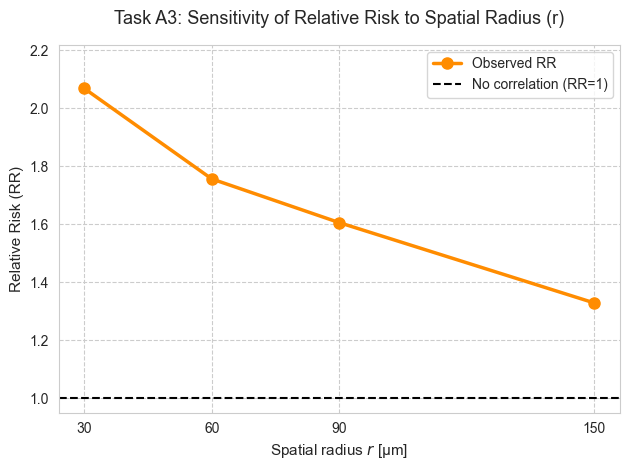

In [22]:
plt.plot(
    df_r_full.index,
    df_r_full['relative_risk'],
    marker='o',
    linestyle='-',
    color='darkorange',
    linewidth=2.5,
    markersize=8,
    label='Observed RR'
)

# Linia referencyjna
plt.axhline(
    1,
    color='black',
    linestyle='--',
    linewidth=1.5,
    label='No correlation (RR=1)'
)

plt.title('Task A3: Sensitivity of Relative Risk to Spatial Radius (r)', fontsize=13, pad=15)
plt.xlabel('Spatial radius $r$ [μm]', fontsize=11)
plt.ylabel('Relative Risk (RR)', fontsize=11)
plt.xticks(radii)

if not df_r_full.empty and not df_r_full['relative_risk'].isna().all():
    plt.ylim(0.95, df_r_full['relative_risk'].max() + 0.15)

plt.legend(frameon=True, loc='upper right')
plt.tight_layout()

save_path = OUTPUT_ROOT / 'parameter_robustness_radius.png'
plt.savefig(save_path, dpi=300)
print(f"\nPlot successfully saved to: {save_path}")

plt.show()


### Task A3: Parameter Recommendation and Justification

**Recommended parameter value:** $r = 60\,\mu\text{m}$

#### **Justification:**

* **Statistical Robustness:**
    A spatial radius of $r = 60\,\mu\text{m}$ offers the optimal balance for tracking signaling dependencies. While $r = 30\,\mu\text{m}$ yields the highest Relative Risk ($RR = 2.07$), it results in a very low average of only $2.85$ neighbors per cell. Such a small sample size introduces statistical volatility and risks excluding true physically adjacent neighbors due to irregular cell shapes or tracking offsets. Conversely, expanding the radius to $150\,\mu\text{m}$ incorporates an average of $80.4$ neighbors. This massive inclusion dilutes the measured effect ($RR$ drops to $1.34$) because genuine local signaling events are overwhelmed by uncorrelated background noise from distant cells.

* **Biological Reasoning:**
    Biologically, $60\,\mu\text{m}$ spans approximately $1.5$ to $2$ epithelial cell diameters. This distance perfectly aligns with the effective range of rapid, short-range paracrine signaling diffusion (e.g., secretome-mediated ERK waves). Choosing this value ensures the reliable capture of direct cell-to-cell communication while successfully filtering out uncoordinated population-level activity that does not reflect true intercellular relay.

---